In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, log_loss, accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
directory = 'Training'
directory2 = 'Testing'

In [3]:
File=[]
for file in os.listdir(directory):
    File+=[file]
print(File)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [4]:
dataset=[]
mapping={'no_tumor':0, 'pituitary_tumor':1, 'meningioma_tumor':2, 'glioma_tumor':3}
count=0

for file in os.listdir(directory):
    path=os.path.join(directory,file)
    for im in os.listdir(path):
        image=load_img(os.path.join(path,im), grayscale=False, color_mode='rgb', target_size=(150,150))
        image=img_to_array(image)
        image=image/255.0
        dataset.append([image,count])     
    count=count+1

In [5]:
testset=[]
mapping={'no_tumor':0, 'pituitary_tumor':1, 'meningioma_tumor':2, 'glioma_tumor':3}
count=0

for file in os.listdir(directory2):
    path=os.path.join(directory2,file)
    for im in os.listdir(path):
        image=load_img(os.path.join(path,im), grayscale=False, color_mode='rgb', target_size=(150,150))
        image=img_to_array(image)
        image=image/255.0
        testset.append([image,count])         
    count=count+1

In [6]:
data,labels0=zip(*dataset)
test,testlabels0=zip(*testset)

In [7]:
labels1=to_categorical(labels0)
data=np.array(data)
labels=np.array(labels1)
print(data.shape)
print(labels.shape)

(2870, 150, 150, 3)
(2870, 4)


In [8]:
testlabels1=to_categorical(testlabels0)
test=np.array(test)
testlabels=np.array(testlabels1)
print(test.shape)
print(testlabels.shape)

(394, 150, 150, 3)
(394, 4)


In [9]:
data2=data.reshape(-1,150,150,3)
test2=test.reshape(-1,150,150,3)

In [10]:
trainx,testx,trainy,testy=train_test_split(data,labels,test_size=0.2,random_state=44)

In [11]:
print(trainx.shape)
print(testx.shape)
print(trainy.shape)
print(testy.shape)

(2296, 150, 150, 3)
(574, 150, 150, 3)
(2296, 4)
(574, 4)


In [12]:
datagen = ImageDataGenerator(horizontal_flip=True,vertical_flip=True,rotation_range=20,zoom_range=0.2,
                    width_shift_range=0.2,height_shift_range=0.2,shear_range=0.1,fill_mode="nearest")

In [13]:
pretrained_model3 = tf.keras.applications.DenseNet201(input_shape=(150,150,3),include_top=False,weights='imagenet',pooling='avg')
pretrained_model3.trainable = False

In [14]:
inputs3 = pretrained_model3.input
x3 = tf.keras.layers.Dense(128, activation='relu')(pretrained_model3.output)
outputs3 = tf.keras.layers.Dense(4, activation='softmax')(x3)
model = tf.keras.Model(inputs=inputs3, outputs=outputs3)
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [16]:
his=model.fit(datagen.flow(trainx,trainy,batch_size=32),validation_data=(testx,testy),epochs=45)

Epoch 1/45
72/72 [==============================] - 86s 1s/step - loss: 0.4613 - accuracy: 0.8293 - val_loss: 0.4574 - val_accuracy: 0.8275
Epoch 2/45
72/72 [==============================] - 87s 1s/step - loss: 0.4527 - accuracy: 0.8319 - val_loss: 0.4601 - val_accuracy: 0.8275
Epoch 3/45
72/72 [==============================] - 87s 1s/step - loss: 0.4183 - accuracy: 0.8419 - val_loss: 0.5609 - val_accuracy: 0.7962
Epoch 4/45
72/72 [==============================] - 85s 1s/step - loss: 0.4173 - accuracy: 0.8445 - val_loss: 0.4384 - val_accuracy: 0.8328
Epoch 5/45
72/72 [==============================] - 86s 1s/step - loss: 0.3644 - accuracy: 0.8672 - val_loss: 0.4721 - val_accuracy: 0.8171
Epoch 6/45
72/72 [==============================] - 86s 1s/step - loss: 0.4058 - accuracy: 0.8467 - val_loss: 0.5567 - val_accuracy: 0.7944
Epoch 7/45
72/72 [==============================] - 85s 1s/step - loss: 0.3403 - accuracy: 0.8702 - val_loss: 0.3758 - val_accuracy: 0.8537
Epoch 8/45
72/72 [==

In [17]:
y_pred=model.predict(testx)
pred=np.argmax(y_pred,axis=1)
ground = np.argmax(testy,axis=1)
print(classification_report(ground,pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       157
           1       0.96      0.59      0.73       170
           2       0.92      0.95      0.93        81
           3       0.79      1.00      0.88       166

    accuracy                           0.86       574
   macro avg       0.88      0.87      0.86       574
weighted avg       0.87      0.86      0.85       574



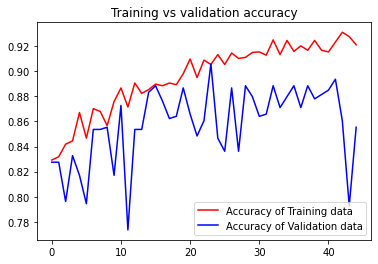

<Figure size 432x288 with 0 Axes>

In [18]:
get_acc = his.history['accuracy']
value_acc = his.history['val_accuracy']
get_loss = his.history['loss']
validation_loss = his.history['val_loss']

epochs = range(len(get_acc))
plt.plot(epochs, get_acc, 'r', label='Accuracy of Training data')
plt.plot(epochs, value_acc, 'b', label='Accuracy of Validation data')
plt.title('Training vs validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()

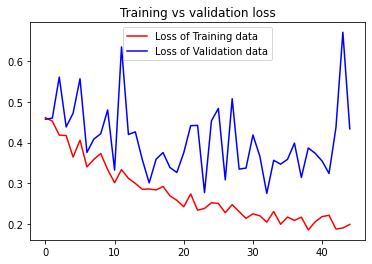

<Figure size 432x288 with 0 Axes>

In [19]:
epochs = range(len(get_loss))
plt.plot(epochs, get_loss, 'r', label='Loss of Training data')
plt.plot(epochs, validation_loss, 'b', label='Loss of Validation data')
plt.title('Training vs validation loss')
plt.legend(loc=0)
plt.figure()
plt.show()

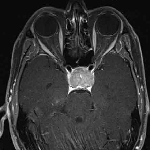

In [20]:
load_img("Testing/pituitary_tumor/image(31).jpg",target_size=(150,150))

In [21]:
load_img("Testing/pituitary_tumor/image(31).jpg",target_size=(150,150))
image=img_to_array(image) 
image=image/255.0
prediction_image=np.array(image)
prediction_image= np.expand_dims(image, axis=0)

In [22]:
reverse_mapping={0:'no_tumor', 1:'pituitary_tumor', 2:'meningioma_tumor', 3:'glioma_tumor'}

def mapper(value):
    return reverse_mapping[value]

prediction=model.predict(prediction_image)
value=np.argmax(prediction)
move_name=mapper(value)
print("Prediction is {}.".format(move_name))

Prediction is pituitary_tumor.


In [23]:
densenet="hist.h5"
model.save(densenet)        #saving the model

In [24]:
from tensorflow import keras
model = keras.models.load_model('hist.h5')      #loading the model


load_img("Testing/pituitary_tumor/image(31).jpg",target_size=(150,150))
image=img_to_array(image) 
image=image/255.0
prediction_image=np.array(image)
prediction_image= np.expand_dims(image, axis=0)


In [25]:
reverse_mapping={0:'no_tumor', 1:'pituitary_tumor', 2:'meningioma_tumor', 3:'glioma_tumor'}

def mapper(value):
    return reverse_mapping[value]

prediction=model.predict(prediction_image)
value=np.argmax(prediction)
move_name=mapper(value)
print("Prediction is {}.".format(move_name))

Prediction is pituitary_tumor.


In [26]:
import tensorflow as tf

# Convert the model.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model.
with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\paula\AppData\Local\Temp\tmpxc8xm1u9\assets
